# Experiment 002 — YOLOv11n Baseline for PCB Defect Detection — Kaggle Dataset (200 Epochs)

**Objective:** Train a YOLOv11-nano model on the Kaggle PCB Defect Dataset to establish a baseline for PCB defect detection across 6 defect classes.

| Property | Value |
|---|---|
| Model | YOLOv11n (nano) |
| Dataset | Kaggle PCB Defect Dataset (norbertelter) — 600×600 sub-images, pre-augmented |
| Image Size | 640 (YOLO resizes from 600×600 crops) |
| Epochs | 200 |
| Batch Size | 16 |
| Classes | mouse_bite, spur, missing_hole, short, open_circuit, spurious_copper |

**Dataset note:** Images are cropped into 600×600 sub-images. The dataset is already augmented with ~9920 train and ~2508 test images.

**Prerequisites:** Place your Kaggle API token at `~/.kaggle/kaggle.json` (download from kaggle.com → Account → API → Create New Token).

## 1. Setup & Installs

In [1]:
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    print(f"Number of GPUs available: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version (PyTorch build): {torch.version.cuda}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
else:
    print("CUDA is not available on this system or PyTorch was installed without CUDA support.")


CUDA Available: True
Number of GPUs available: 1
GPU Name: NVIDIA GeForce RTX 3090
CUDA Version (PyTorch build): 12.4
cuDNN Enabled: True
cuDNN Version: 90100


In [2]:
!pip install ultralytics kagglehub wandb --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import wandb
wandb.login(key="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")
print("WandB login successful.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/vector/.netrc
wandb: Currently logged in as: abdulllah01 (abdulllah01-fast-nuces) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


WandB login successful.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("norbertelter/pcb-defect-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2


## 3. Imports & Configuration

In [5]:
import os
import random
import datetime
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

from ultralytics import YOLO
import ultralytics
print(f"ultralytics version: {ultralytics.__version__}")

ultralytics version: 8.4.41


In [6]:
# ---- Experiment Config ----
EXP_NAME      = "exp_002_yolov11n_kaggle_pcb_200ep"
RUN_ID        = "run1"
WANDB_PROJECT = "pcb-defect-detection"
WANDB_RUN     = f"{EXP_NAME}_{RUN_ID}"
SEED          = 42
MODEL_ARCH    = "yolo11n.pt"
EPOCHS        = 200
BATCH_SIZE    = 16
IMG_SIZE      = 640
DEVICE        = 0                     # GPU 0; set to 'cpu' if no GPU

# ---- Paths ----
DATASET_DIR   = Path(path) / "pcb-defect-dataset"
DATA_YAML     = DATASET_DIR / "data.yaml"

_cwd = Path(os.getcwd())
PROJECT_ROOT  = _cwd.parent if _cwd.name == "experiments" else _cwd
RESULTS_DIR   = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_IMG_DIR = DATASET_DIR / "train" / "images"
TRAIN_LBL_DIR = DATASET_DIR / "train" / "labels"
VALID_IMG_DIR = DATASET_DIR / "val" / "images"
VALID_LBL_DIR = DATASET_DIR / "val" / "labels"
TEST_IMG_DIR  = DATASET_DIR / "test" / "images"
TEST_LBL_DIR  = DATASET_DIR / "test" / "labels"

CLASS_NAMES = ['mouse_bite', 'spur', 'missing_hole', 'short', 'open_circuit', 'spurious_copper']
NUM_CLASSES = len(CLASS_NAMES)

CFG = {
    "exp_name":       EXP_NAME,
    "run_id":         RUN_ID,
    "seed":           SEED,
    "model_arch":     MODEL_ARCH,
    "epochs":         EPOCHS,
    "batch_size":     BATCH_SIZE,
    "img_size":       IMG_SIZE,
    "device":         str(DEVICE),
    "dataset":        "norbertelter/pcb-defect-dataset",
    "dataset_note":   "pre-augmented 600x600 sub-images",
    "num_classes":    NUM_CLASSES,
    "class_names":    CLASS_NAMES,
    "patience":       50,
    "save_period":    50,
}

print(f"Experiment  : {EXP_NAME}")
print(f"Run         : {RUN_ID}")
print(f"SEED        : {SEED}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Data YAML   : {DATA_YAML}")
print(f"Results dir : {RESULTS_DIR / EXP_NAME}")

Experiment  : exp_002_yolov11n_kaggle_pcb_200ep
Run         : run1
SEED        : 42
Project root: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection
Dataset dir : /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset
Data YAML   : /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/data.yaml
Results dir : /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep


In [7]:
import platform

run = wandb.init(
    project=WANDB_PROJECT,
    name=WANDB_RUN,
    config=CFG,
    tags=["yolov11n", "kaggle-dataset", "baseline", "local-pc"],
    notes="YOLOv11n baseline on Kaggle pre-augmented PCB dataset (norbertelter/pcb-defect-dataset). 600x600 sub-images, 200 epochs. Running on local PC.",
)
print(f"WandB run  : {run.name}")
print(f"WandB URL  : {run.url}")

sys_info = {
    "python_version":      platform.python_version(),
    "platform":            platform.platform(),
    "ultralytics_version": ultralytics.__version__,
    "torch_version":       torch.__version__,
    "cuda_available":      str(torch.cuda.is_available()),
    "gpu_name":            torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A",
    "cuda_version":        torch.version.cuda if torch.cuda.is_available() else "N/A",
}
sys_table = wandb.Table(columns=list(sys_info.keys()), data=[list(sys_info.values())])
wandb.log({"system_info": sys_table})
print("System info logged to WandB.")

WandB run  : exp_002_yolov11n_kaggle_pcb_200ep_run1
WandB URL  : https://wandb.ai/abdulllah01-fast-nuces/pcb-defect-detection/runs/l0e6970u
System info logged to WandB.


### 4.1 Split Sizes

In [8]:
def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Seeds set to {SEED}.")

Seeds set to 42.


In [9]:
train_images = list(TRAIN_IMG_DIR.glob("*"))
valid_images = list(VALID_IMG_DIR.glob("*"))
test_images  = list(TEST_IMG_DIR.glob("*"))

split_df = pd.DataFrame({
    "Split": ["Train", "Validation", "Test", "Total"],
    "Images": [len(train_images), len(valid_images), len(test_images),
               len(train_images) + len(valid_images) + len(test_images)]
})
split_df

,Split,Images
0,Train,8534
1,Validation,1066
2,Test,1068
3,Total,10668


In [10]:
# ---- Log dataset split sizes to WandB ----
split_table = wandb.Table(dataframe=split_df)
wandb.log({"eda/split_sizes": split_table})
print("Dataset split sizes logged to WandB.")

Dataset split sizes logged to WandB.


### 4.2 Class Distribution

In [11]:
def count_classes(label_dir, num_classes):
    """Count annotation instances of each class from YOLO label files."""
    counts = Counter()
    for lbl_file in Path(label_dir).glob("*.txt"):
        with open(lbl_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

train_counts = count_classes(TRAIN_LBL_DIR, NUM_CLASSES)
valid_counts = count_classes(VALID_LBL_DIR, NUM_CLASSES)
test_counts  = count_classes(TEST_LBL_DIR, NUM_CLASSES)

dist_df = pd.DataFrame({
    "Class": CLASS_NAMES,
    "Train": [train_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "Valid": [valid_counts.get(i, 0) for i in range(NUM_CLASSES)],
    "Test":  [test_counts.get(i, 0) for i in range(NUM_CLASSES)],
})
dist_df["Total"] = dist_df["Train"] + dist_df["Valid"] + dist_df["Test"]
dist_df

,Class,Train,Valid,Test,Total
0,mouse_bite,2980,372,332,3684
1,spur,2919,369,348,3636
2,missing_hole,2902,331,379,3612
3,short,2731,411,366,3508
4,open_circuit,2844,359,345,3548
5,spurious_copper,2966,322,388,3676


In [12]:
# ---- Log class distribution table to WandB ----
dist_table = wandb.Table(dataframe=dist_df)
wandb.log({"eda/class_distribution": dist_table})
print("Class distribution table logged to WandB.")

Class distribution table logged to WandB.


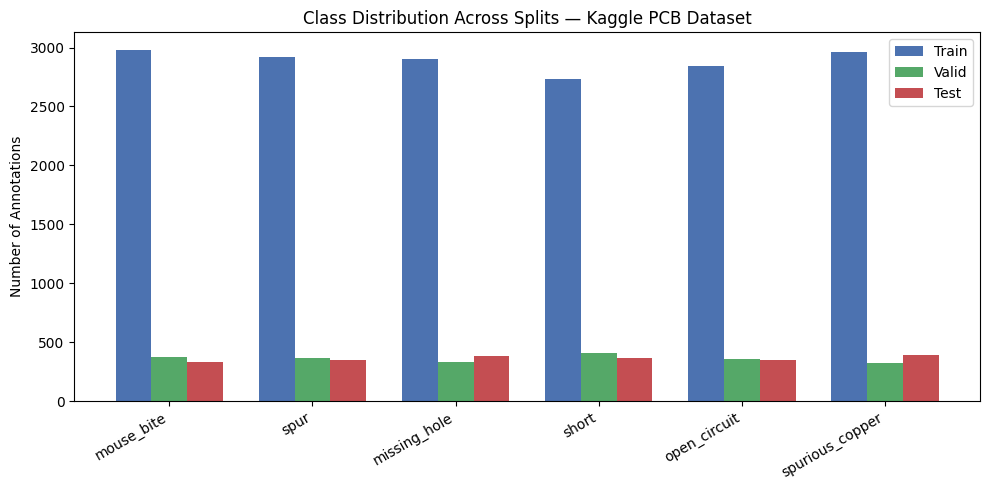

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(NUM_CLASSES)
width = 0.25
ax.bar(x - width, dist_df["Train"], width, label="Train", color="#4C72B0")
ax.bar(x,         dist_df["Valid"], width, label="Valid", color="#55A868")
ax.bar(x + width, dist_df["Test"],  width, label="Test",  color="#C44E52")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
ax.set_ylabel("Number of Annotations")
ax.set_title("Class Distribution Across Splits — Kaggle PCB Dataset")
ax.legend()
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / f"{EXP_NAME}_class_distribution.png"), dpi=150)
plt.show()

In [14]:
# ---- Log class distribution plot to WandB ----
dist_plot_path = RESULTS_DIR / f"{EXP_NAME}_class_distribution.png"
if dist_plot_path.exists():
    wandb.log({"eda/class_distribution_plot": wandb.Image(
        str(dist_plot_path), caption="Class distribution across train/val/test splits"
    )})
    print("Class distribution plot logged to WandB.")

Class distribution plot logged to WandB.


### 4.3 Sample Images with Bounding Boxes

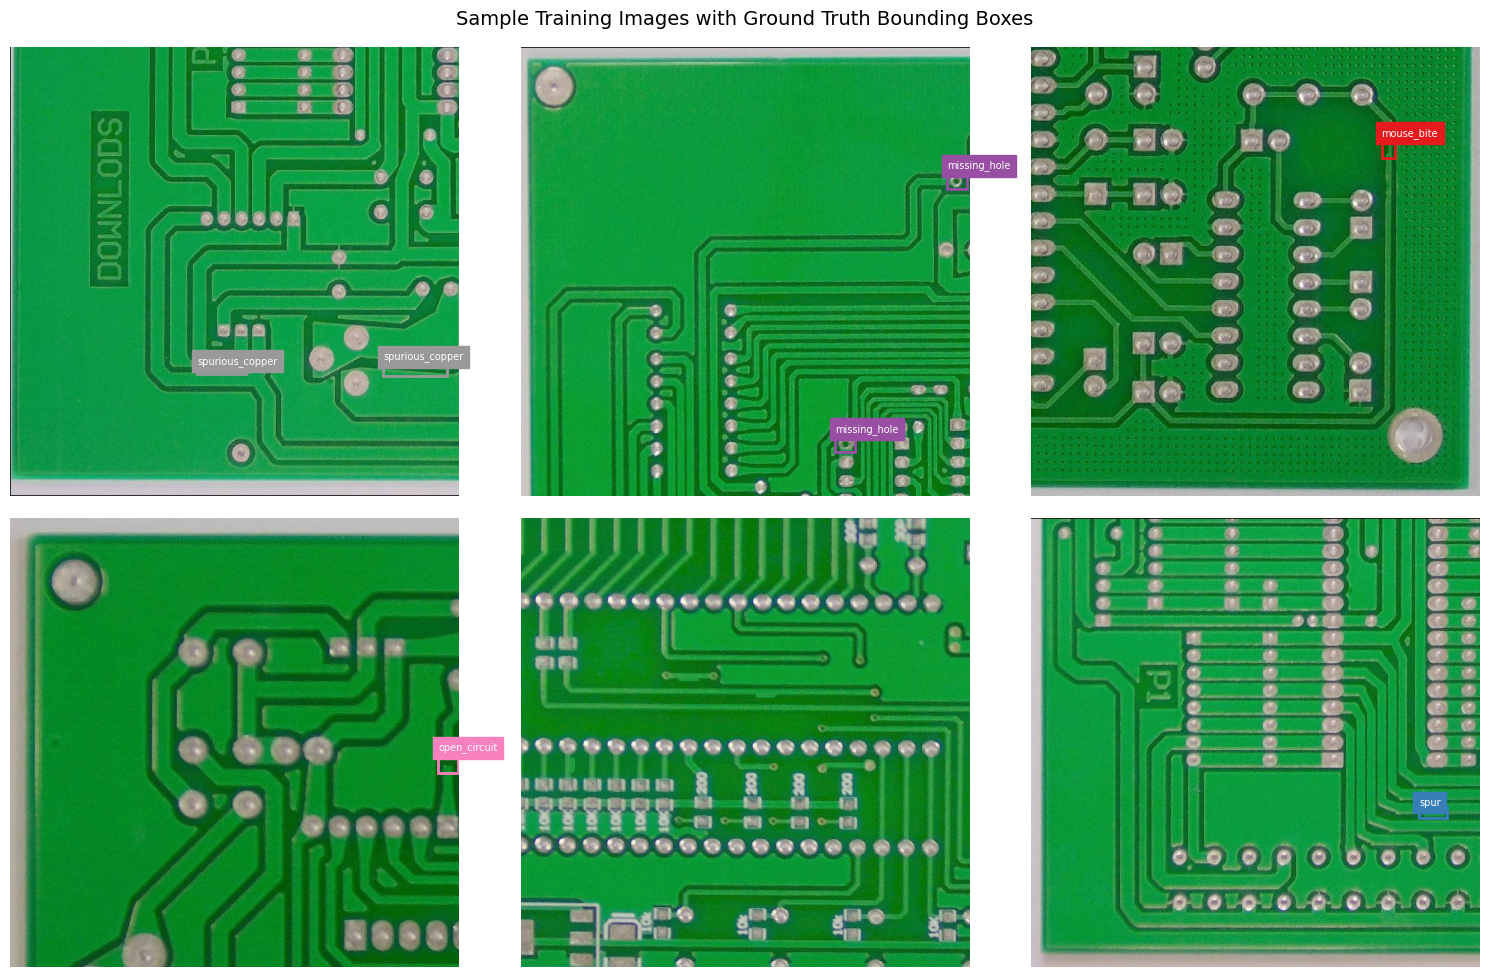

In [15]:
def draw_yolo_boxes(img_path, lbl_path, class_names, ax):
    """Draw YOLO bounding boxes on an image."""
    img = mpimg.imread(str(img_path))
    h, w = img.shape[:2]
    ax.imshow(img)
    colors = plt.cm.Set1(np.linspace(0, 1, len(class_names)))

    if Path(lbl_path).exists():
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = [float(v) for v in parts[1:5]]
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                rect_w = bw * w
                rect_h = bh * h
                rect = plt.Rectangle((x1, y1), rect_w, rect_h,
                                     linewidth=2, edgecolor=colors[cls_id],
                                     facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 2, class_names[cls_id], fontsize=7,
                        color='white', backgroundcolor=colors[cls_id])
    ax.axis('off')


random.seed(42)
sample_imgs = random.sample(train_images, min(6, len(train_images)))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, sample_imgs):
    lbl_name = img_path.stem + ".txt"
    lbl_path = TRAIN_LBL_DIR / lbl_name
    draw_yolo_boxes(img_path, lbl_path, CLASS_NAMES, ax)
plt.suptitle("Sample Training Images with Ground Truth Bounding Boxes", fontsize=14)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / f"{EXP_NAME}_sample_images.png"), dpi=150)
plt.show()

In [16]:
# ---- Log sample images to WandB ----
sample_img_path = RESULTS_DIR / f"{EXP_NAME}_sample_images.png"
if sample_img_path.exists():
    wandb.log({"eda/sample_training_images": wandb.Image(
        str(sample_img_path), caption="Sample training images with GT bounding boxes"
    )})
    print("Sample images logged to WandB.")

Sample images logged to WandB.


## 5. Model Training

Training YOLOv11n for **200 epochs** with early stopping patience of 50.

In [17]:
import yaml

# ---- Fix data.yaml with absolute paths ----
custom_data = {
    'path': str(DATASET_DIR),
    'train': 'train',
    'val': 'val',
    'test': 'test',
    'names': {
        0: 'mouse_bite',
        1: 'spur',
        2: 'missing_hole',
        3: 'short',
        4: 'open_circuit',
        5: 'spurious_copper',
    }
}

with open(str(DATA_YAML), 'w') as f:
    yaml.dump(custom_data, f, default_flow_style=False)

print(f"Fixed data.yaml written to: {DATA_YAML}")
print(f"  path: {DATASET_DIR}")

# ---- Train ----
seed_everything(SEED)

TRAIN_START_TIME = datetime.datetime.now()
print(f"\n{'='*60}")
print(f"  Starting YOLOv11n Training — {EXP_NAME}")
print(f"  Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | ImgSz: {IMG_SIZE}")
print(f"  Start Time: {TRAIN_START_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'='*60}\n")

model = YOLO(MODEL_ARCH)

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RESULTS_DIR),
    name=EXP_NAME,
    exist_ok=True,
    patience=50,
    save=True,
    save_period=50,
    plots=True,
    verbose=True,
    seed=SEED,
    deterministic=True,
)

TRAIN_END_TIME = datetime.datetime.now()
TRAIN_DURATION = TRAIN_END_TIME - TRAIN_START_TIME
print(f"\nTraining completed at: {TRAIN_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total training time  : {TRAIN_DURATION}")

Fixed data.yaml written to: /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/data.yaml
  path: /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset

  Starting YOLOv11n Training — exp_002_yolov11n_kaggle_pcb_200ep
  Epochs: 200 | Batch: 16 | ImgSz: 640
  Start Time: 2026-04-26 20:36:43

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2e

In [18]:
# ---- Log training duration to WandB ----
wandb.log({
    "train/duration_seconds": TRAIN_DURATION.total_seconds(),
    "train/start_time":       TRAIN_START_TIME.isoformat(),
    "train/end_time":         TRAIN_END_TIME.isoformat(),
})
print(f"Training duration logged: {TRAIN_DURATION}")

Training duration logged: 2:14:01.432606


## 6. Validation Metrics

In [19]:
best_model_path = RESULTS_DIR / EXP_NAME / "weights" / "best.pt"
print(f"Loading best model from: {best_model_path}")
best_model = YOLO(str(best_model_path))

val_results = best_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RESULTS_DIR),
    name=f"{EXP_NAME}_val_eval",
    exist_ok=True,
    plots=True,
)

Loading best model from: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
YOLO11n summary (fused): 101 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3192.2±1671.4 MB/s, size: 96.3 KB)
val: Scanning /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/val/labels.cache... 802 images, 264 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1066/1066 745.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 21.8it/s 3.1s0.1s
                   all       1066       1595      0.985      0.987       0.99      0.636
            mouse_bite        140        280      0.983      0.989      0.993      0.661
                  spur        130        262      0.992     

### 6.1 Overall Validation Metrics

In [20]:
val_precision   = val_results.box.mp        # mean Precision
val_recall      = val_results.box.mr        # mean Recall
val_map50       = val_results.box.map50     # mAP@0.5
val_map50_95    = val_results.box.map       # mAP@0.5:0.95
val_f1          = 2 * (val_precision * val_recall) / (val_precision + val_recall + 1e-8)

print("\n" + "="*60)
print("  VALIDATION SET — Overall Metrics")
print("="*60)
val_overall = pd.DataFrame({
    "Metric": ["Precision (P)", "Recall (R)", "F1 Score", "mAP@50", "mAP@50-95"],
    "Value": [f"{val_precision:.4f}", f"{val_recall:.4f}", f"{val_f1:.4f}",
              f"{val_map50:.4f}", f"{val_map50_95:.4f}"]
})
val_overall


  VALIDATION SET — Overall Metrics


,Metric,Value
0,Precision (P),0.9848
1,Recall (R),0.9871
2,F1 Score,0.9860
3,mAP@50,0.9904
4,mAP@50-95,0.6358


In [21]:
# ---- Log val overall metrics to WandB ----
wandb.log({
    "val/precision": val_precision,
    "val/recall":    val_recall,
    "val/f1":        val_f1,
    "val/mAP50":     val_map50,
    "val/mAP50-95":  val_map50_95,
})
print("Val overall metrics logged to WandB.")

Val overall metrics logged to WandB.


### 6.2 Per-Class Validation Metrics

In [22]:
per_class_p       = val_results.box.p
per_class_r       = val_results.box.r
per_class_ap50    = val_results.box.ap50
per_class_ap50_95 = val_results.box.ap
per_class_f1      = 2 * per_class_p * per_class_r / (per_class_p + per_class_r + 1e-8)

per_class_df = pd.DataFrame({
    "Class":    CLASS_NAMES,
    "Precision": [f"{v:.4f}" for v in per_class_p],
    "Recall":    [f"{v:.4f}" for v in per_class_r],
    "F1":        [f"{v:.4f}" for v in per_class_f1],
    "AP@50":     [f"{v:.4f}" for v in per_class_ap50],
    "AP@50-95":  [f"{v:.4f}" for v in per_class_ap50_95],
})

print("\n" + "="*60)
print("  VALIDATION SET — Per-Class Metrics")
print("="*60)
per_class_df


  VALIDATION SET — Per-Class Metrics


,Class,Precision,Recall,F1,AP@50,AP@50-95
0,mouse_bite,0.9831,0.9893,0.9862,0.9926,0.6610
1,spur,0.9921,0.9924,0.9923,0.9890,0.6147
2,missing_hole,0.9956,0.9956,0.9956,0.9950,0.6671
3,short,0.9781,0.9786,0.9783,0.9821,0.6361
4,open_circuit,0.9884,0.9837,0.9860,0.9937,0.6076
5,spurious_copper,0.9714,0.9832,0.9772,0.9902,0.6281


In [23]:
# ---- Log val per-class metrics to WandB ----
val_pc_table = wandb.Table(
    columns=["Class", "Precision", "Recall", "F1", "AP@50", "AP@50-95"]
)
for i, cls in enumerate(CLASS_NAMES):
    val_pc_table.add_data(
        cls,
        float(per_class_p[i]), float(per_class_r[i]), float(per_class_f1[i]),
        float(per_class_ap50[i]), float(per_class_ap50_95[i]),
    )
wandb.log({"val/per_class_metrics": val_pc_table})
print("Val per-class metrics logged to WandB.")

Val per-class metrics logged to WandB.


## 7. Test Set Evaluation

In [24]:
test_results = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    project=str(RESULTS_DIR),
    name=f"{EXP_NAME}_test_eval",
    exist_ok=True,
    plots=True,
)

Ultralytics 8.4.41 🚀 Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 3090, 24115MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 332.8±103.5 MB/s, size: 110.2 KB)
val: Scanning /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/labels... 829 images, 239 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1068/1068 4.0Kit/s 0.3s.1s
val: New cache created: /home/vector/.cache/kagglehub/datasets/norbertelter/pcb-defect-dataset/versions/2/pcb-defect-dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 24.3it/s 2.8s0.0s
                   all       1068       1662      0.987      0.991      0.993      0.635
            mouse_bite        131        262      0.983      0.996      0.993      0.642
                  spur        138        279      0.993      0.984      0.994       0.62
          missing_hole        145        283      0.989      0.

### 7.1 Overall Test Metrics

In [25]:
test_precision   = test_results.box.mp
test_recall      = test_results.box.mr
test_map50       = test_results.box.map50
test_map50_95    = test_results.box.map
test_f1          = 2 * (test_precision * test_recall) / (test_precision + test_recall + 1e-8)

print("\n" + "="*60)
print("  TEST SET — Overall Metrics")
print("="*60)
test_overall = pd.DataFrame({
    "Metric": ["Precision (P)", "Recall (R)", "F1 Score", "mAP@50", "mAP@50-95"],
    "Value": [f"{test_precision:.4f}", f"{test_recall:.4f}", f"{test_f1:.4f}",
              f"{test_map50:.4f}", f"{test_map50_95:.4f}"]
})
test_overall


  TEST SET — Overall Metrics


,Metric,Value
0,Precision (P),0.9874
1,Recall (R),0.9909
2,F1 Score,0.9892
3,mAP@50,0.9931
4,mAP@50-95,0.6348


In [26]:
# ---- Log test overall metrics to WandB ----
wandb.log({
    "test/precision": test_precision,
    "test/recall":    test_recall,
    "test/f1":        test_f1,
    "test/mAP50":     test_map50,
    "test/mAP50-95":  test_map50_95,
})
print("Test overall metrics logged to WandB.")

Test overall metrics logged to WandB.


### 7.2 Per-Class Test Metrics

In [27]:
test_pc_p       = test_results.box.p
test_pc_r       = test_results.box.r
test_pc_ap50    = test_results.box.ap50
test_pc_ap50_95 = test_results.box.ap
test_pc_f1      = 2 * test_pc_p * test_pc_r / (test_pc_p + test_pc_r + 1e-8)

test_pc_df = pd.DataFrame({
    "Class":    CLASS_NAMES,
    "Precision": [f"{v:.4f}" for v in test_pc_p],
    "Recall":    [f"{v:.4f}" for v in test_pc_r],
    "F1":        [f"{v:.4f}" for v in test_pc_f1],
    "AP@50":     [f"{v:.4f}" for v in test_pc_ap50],
    "AP@50-95":  [f"{v:.4f}" for v in test_pc_ap50_95],
})

print("\n" + "="*60)
print("  TEST SET — Per-Class Metrics")
print("="*60)
test_pc_df


  TEST SET — Per-Class Metrics


,Class,Precision,Recall,F1,AP@50,AP@50-95
0,mouse_bite,0.9831,0.9962,0.9896,0.9929,0.6417
1,spur,0.9928,0.9838,0.9882,0.9943,0.6200
2,missing_hole,0.9895,0.9965,0.9930,0.9946,0.6551
3,short,0.9852,0.9891,0.9871,0.9921,0.6346
4,open_circuit,0.9979,1.0000,0.9989,0.9950,0.6246
5,spurious_copper,0.9761,0.9799,0.9780,0.9899,0.6329


In [28]:
# ---- Log test per-class metrics to WandB ----
test_pc_table = wandb.Table(
    columns=["Class", "Precision", "Recall", "F1", "AP@50", "AP@50-95"]
)
for i, cls in enumerate(CLASS_NAMES):
    test_pc_table.add_data(
        cls,
        float(test_pc_p[i]), float(test_pc_r[i]), float(test_pc_f1[i]),
        float(test_pc_ap50[i]), float(test_pc_ap50_95[i]),
    )
wandb.log({"test/per_class_metrics": test_pc_table})
print("Test per-class metrics logged to WandB.")

Test per-class metrics logged to WandB.


## 8. Export Results Summary

In [29]:
summary_path = RESULTS_DIR / f"{EXP_NAME}_summary.csv"

summary_rows = []
for split_name, res in [("Validation", val_results), ("Test", test_results)]:
    mp = res.box.mp
    mr = res.box.mr
    m50 = res.box.map50
    m50_95 = res.box.map
    f1 = 2 * mp * mr / (mp + mr + 1e-8)
    summary_rows.append({
        "Split": split_name,
        "Precision": round(mp, 4),
        "Recall": round(mr, 4),
        "F1": round(f1, 4),
        "mAP@50": round(m50, 4),
        "mAP@50-95": round(m50_95, 4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(str(summary_path), index=False)
print(f"Results summary saved to: {summary_path}")
summary_df

Results summary saved to: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep_summary.csv


,Split,Precision,Recall,F1,mAP@50,mAP@50-95
0,Validation,0.9848,0.9871,0.9860,0.9904,0.6358
1,Test,0.9874,0.9909,0.9892,0.9931,0.6348


In [30]:
# ---- Log Val vs Test comparison to WandB ----
wandb_summary_table = wandb.Table(
    columns=["Split", "Precision", "Recall", "F1", "mAP@50", "mAP@50-95"]
)
for _, row in summary_df.iterrows():
    wandb_summary_table.add_data(
        row["Split"], row["Precision"], row["Recall"],
        row["F1"], row["mAP@50"], row["mAP@50-95"],
    )
wandb.log({"val_vs_test_summary": wandb_summary_table})
print("Val vs Test summary table logged to WandB.")

Val vs Test summary table logged to WandB.


## 9. Training Curves

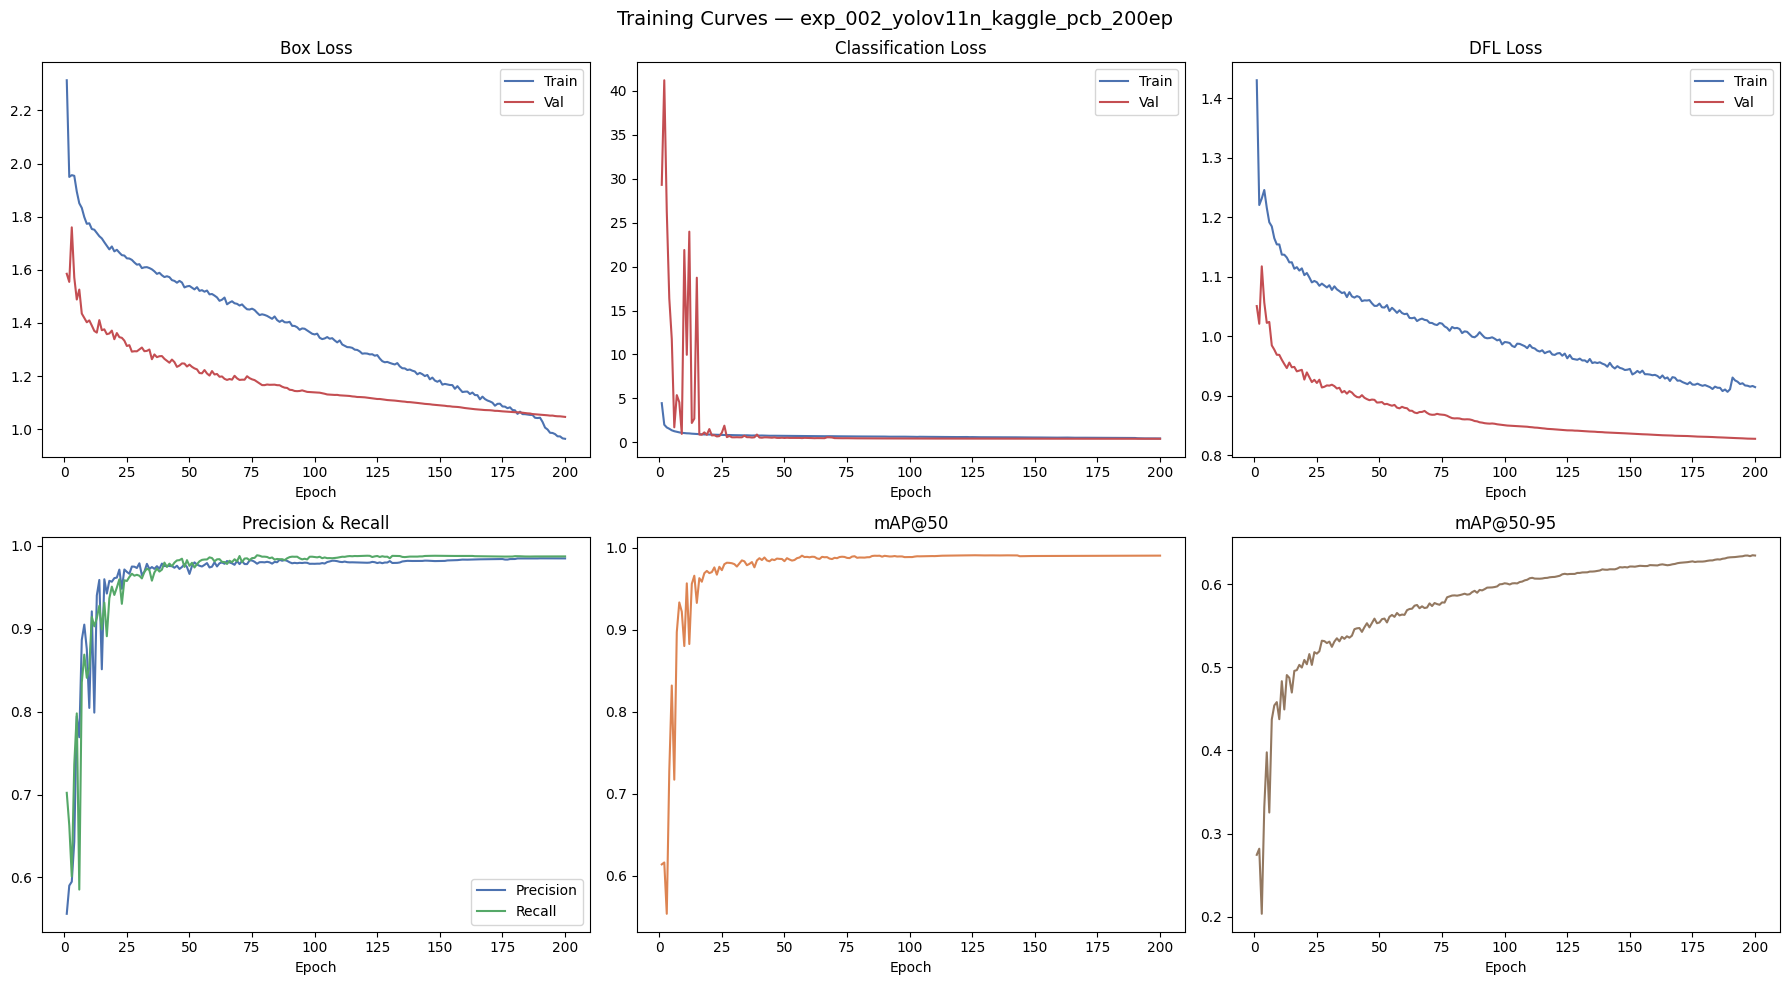

Training curves saved.


In [31]:
results_csv = RESULTS_DIR / EXP_NAME / "results.csv"
if results_csv.exists():
    res_df = pd.read_csv(str(results_csv))
    res_df.columns = res_df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Box loss
    axes[0, 0].plot(res_df["epoch"], res_df["train/box_loss"], label="Train", color="#4C72B0")
    axes[0, 0].plot(res_df["epoch"], res_df["val/box_loss"],   label="Val",   color="#C44E52")
    axes[0, 0].set_title("Box Loss"); axes[0, 0].legend(); axes[0, 0].set_xlabel("Epoch")

    # Cls loss
    axes[0, 1].plot(res_df["epoch"], res_df["train/cls_loss"], label="Train", color="#4C72B0")
    axes[0, 1].plot(res_df["epoch"], res_df["val/cls_loss"],   label="Val",   color="#C44E52")
    axes[0, 1].set_title("Classification Loss"); axes[0, 1].legend(); axes[0, 1].set_xlabel("Epoch")

    # DFL loss
    axes[0, 2].plot(res_df["epoch"], res_df["train/dfl_loss"], label="Train", color="#4C72B0")
    axes[0, 2].plot(res_df["epoch"], res_df["val/dfl_loss"],   label="Val",   color="#C44E52")
    axes[0, 2].set_title("DFL Loss"); axes[0, 2].legend(); axes[0, 2].set_xlabel("Epoch")

    # Precision & Recall
    axes[1, 0].plot(res_df["epoch"], res_df["metrics/precision(B)"], label="Precision", color="#4C72B0")
    axes[1, 0].plot(res_df["epoch"], res_df["metrics/recall(B)"],    label="Recall",    color="#55A868")
    axes[1, 0].set_title("Precision & Recall"); axes[1, 0].legend(); axes[1, 0].set_xlabel("Epoch")

    # mAP@50
    axes[1, 1].plot(res_df["epoch"], res_df["metrics/mAP50(B)"], color="#DD8452")
    axes[1, 1].set_title("mAP@50"); axes[1, 1].set_xlabel("Epoch")

    # mAP@50-95
    axes[1, 2].plot(res_df["epoch"], res_df["metrics/mAP50-95(B)"], color="#937860")
    axes[1, 2].set_title("mAP@50-95"); axes[1, 2].set_xlabel("Epoch")

    plt.suptitle(f"Training Curves — {EXP_NAME}", fontsize=14)
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / f"{EXP_NAME}_training_curves.png"), dpi=150)
    plt.show()
    print("Training curves saved.")
else:
    print(f"results.csv not found at {results_csv}")

In [32]:
# ---- Log training curves image to WandB ----
curves_img = RESULTS_DIR / f"{EXP_NAME}_training_curves.png"
if curves_img.exists():
    wandb.log({"training_curves": wandb.Image(str(curves_img), caption="Training curves")})
    print("Training curves image logged to WandB.")

# ---- Log all YOLO diagnostic plots ----
def log_yolo_plots(run_dir: Path, prefix: str = "yolo_plots"):
    plot_files = list(run_dir.glob("*.png")) + list(run_dir.glob("*.jpg"))
    logged = {}
    for f in sorted(plot_files):
        key = f"{prefix}/{f.stem}"
        logged[key] = wandb.Image(str(f))
    if logged:
        wandb.log(logged)
        print(f"Logged {len(logged)} diagnostic plots from {run_dir.name}")

log_yolo_plots(RESULTS_DIR / EXP_NAME, prefix="train_plots")

for eval_tag in [f"{EXP_NAME}_val_eval", f"{EXP_NAME}_test_eval"]:
    eval_dir = RESULTS_DIR / eval_tag
    if eval_dir.exists():
        prefix = "val_eval_plots" if "val_eval" in eval_tag else "test_eval_plots"
        log_yolo_plots(eval_dir, prefix=prefix)

Training curves image logged to WandB.
Logged 20 diagnostic plots from exp_002_yolov11n_kaggle_pcb_200ep
Logged 12 diagnostic plots from exp_002_yolov11n_kaggle_pcb_200ep_val_eval
Logged 12 diagnostic plots from exp_002_yolov11n_kaggle_pcb_200ep_test_eval


## 10. Final Summary

In [33]:
print("\n" + "="*60)
print("  EXPERIMENT COMPLETE")
print(f"  {EXP_NAME}")
print(f"  Timestamp: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)
print(f"\nBest weights:    {RESULTS_DIR / EXP_NAME / 'weights' / 'best.pt'}")
print(f"Last weights:    {RESULTS_DIR / EXP_NAME / 'weights' / 'last.pt'}")
print(f"Results CSV:     {RESULTS_DIR / EXP_NAME / 'results.csv'}")
print(f"Summary CSV:     {RESULTS_DIR / f'{EXP_NAME}_summary.csv'}")
print(f"Training curves: {RESULTS_DIR / f'{EXP_NAME}_training_curves.png'}")


  EXPERIMENT COMPLETE
  exp_002_yolov11n_kaggle_pcb_200ep
  Timestamp: 2026-04-26 22:51:04

Best weights:    /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep/weights/best.pt
Last weights:    /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep/weights/last.pt
Results CSV:     /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep/results.csv
Summary CSV:     /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep_summary.csv
Training curves: /home/vector/Documents/abdullah_workspace/PCB_Defect_Dectection/results/exp_002_yolov11n_kaggle_pcb_200ep_training_curves.png


In [34]:
# ---- Log model weights as WandB Artifact ----
best_weights = RESULTS_DIR / EXP_NAME / "weights" / "best.pt"
if best_weights.exists():
    artifact = wandb.Artifact(
        name=f"{EXP_NAME}_weights",
        type="model",
        description=f"Best YOLOv11n weights — {EXP_NAME}",
        metadata=CFG,
    )
    artifact.add_file(str(best_weights), name="best.pt")
    last_weights = RESULTS_DIR / EXP_NAME / "weights" / "last.pt"
    if last_weights.exists():
        artifact.add_file(str(last_weights), name="last.pt")
    wandb.log_artifact(artifact)
    print("Model artifact logged to WandB.")

# ---- Set WandB run summary ----
wandb.run.summary["val/precision"]          = val_precision
wandb.run.summary["val/recall"]             = val_recall
wandb.run.summary["val/f1"]                 = val_f1
wandb.run.summary["val/mAP50"]              = val_map50
wandb.run.summary["val/mAP50-95"]           = val_map50_95
wandb.run.summary["test/precision"]         = test_precision
wandb.run.summary["test/recall"]            = test_recall
wandb.run.summary["test/f1"]               = test_f1
wandb.run.summary["test/mAP50"]             = test_map50
wandb.run.summary["test/mAP50-95"]          = test_map50_95
wandb.run.summary["train/duration_seconds"] = TRAIN_DURATION.total_seconds()

wandb.finish()
print("WandB run finished.")

Model artifact logged to WandB.


test/f1,▁
test/mAP50,▁
test/mAP50-95,▁
test/precision,▁
test/recall,▁
train/duration_seconds,▁
val/f1,▁
val/mAP50,▁
val/mAP50-95,▁
val/precision,▁
+1,...


WandB run finished.
